In [1]:
import os
print(os.getcwd())
print(os.listdir())

/Users/rooneysingh0027/Documents/EE656 Project - 2
['.DS_Store', 'experimentation_local.ipynb', 'svm_classifier.py', 'feature_extraction.py', 'feature_selectors.py', 'experimentation.ipynb', 'AirCompressor_Data']


In [2]:
DATA_DIR = "/Users/rooneysingh0027/Documents/EE656 Project - 2/AirCompressor_Data"

In [3]:
# verifying
print(os.path.exists(DATA_DIR))
print(os.listdir(DATA_DIR))

True
['NRV', '.DS_Store', 'Healthy', 'LOV', 'Flywheel', 'LIV', 'Bearing', 'Piston', 'Riderbelt']


#### Data reading verification

In [4]:
CLASSES = ['Flywheel', 'Bearing', 'Healthy', 'Riderbelt', 'LOV', 'LIV', 'NRV', 'Piston']

In [5]:
import numpy as np

## Preprocessing

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, firwin, filtfilt

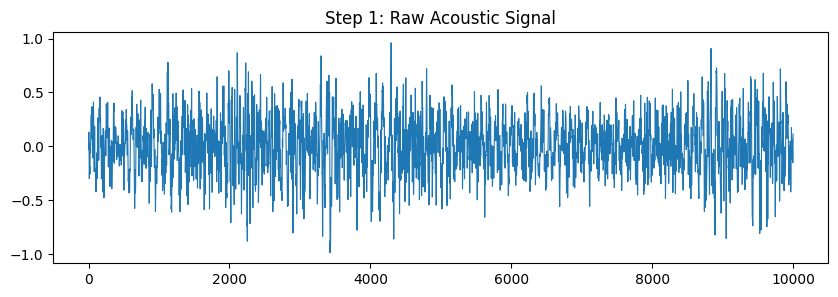

In [7]:
# CELL 1: Setup and Load ONE Test Signal
# We will use this single 'healthy' signal to test our entire pipeline cell-by-cell.

import numpy as np
import matplotlib.pyplot as plt
import os

# Update this path to where your 'healthy' folder is in Colab/Drive
FOLDER_PATH = DATA_DIR + '/Healthy'

# Grab the very first .dat file in the folder
test_file = [f for f in os.listdir(FOLDER_PATH) if f.endswith('.dat')][0]
filepath = os.path.join(FOLDER_PATH, test_file)

# Load and scale the binary data (ignoring DAQ spikes)
with open(filepath, 'r') as f:
    raw_signal = np.array([float(x) for x in f.read().split(',')], dtype=np.float32)
# TEST: Plot the first 0.2 seconds to verify it loaded correctly
plt.figure(figsize=(10, 3))
plt.plot(raw_signal[:10000], color='#1f77b4', linewidth=0.8)
plt.title("Step 1: Raw Acoustic Signal")
plt.show()

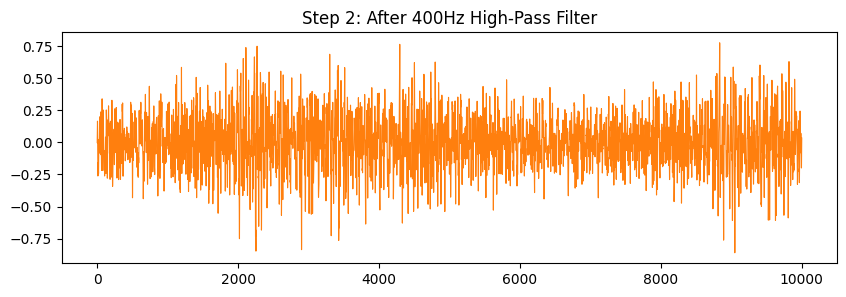

In [8]:
# CELL 2: Apply High-Pass Filter (400 Hz)
# Removes mechanical rumble. We use FIR because it doesn't distort phase.

from scipy.signal import firwin, filtfilt

fs = 50000 # 50 kHz sampling rate
nyq = 0.5 * fs

# 1. Create a 101-tap FIR filter (400 Hz cutoff)
fir_taps = firwin(101, 400/nyq, pass_zero=False)

# 2. Apply the filter to our raw_signal
hp_filtered = filtfilt(fir_taps, [1.0], raw_signal)

# TEST: Plot the result to ensure the signal wasn't destroyed
plt.figure(figsize=(10, 3))
plt.plot(hp_filtered[:10000], color='#ff7f0e', linewidth=0.8)
plt.title("Step 2: After 400Hz High-Pass Filter")
plt.show()

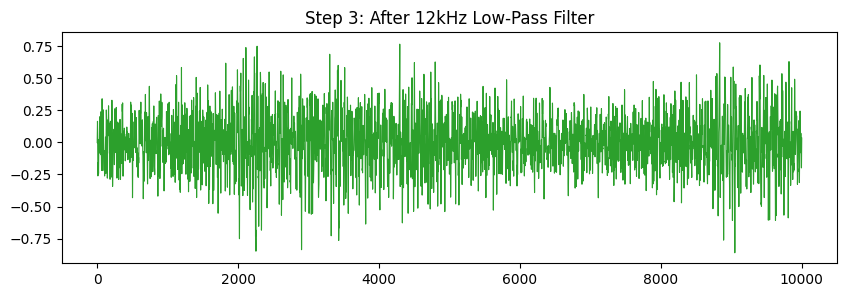

In [9]:
# CELL 3: Apply Low-Pass Butterworth Filter (12 kHz, 18th Order)
# Removes high-frequency electrical noise and hiss.
# Uses 'sos' (Second-Order Sections) to guarantee mathematical stability for high orders.

from scipy.signal import butter, sosfiltfilt

# 1. Design the 18th-order filter using 'sos' format
sos_lp = butter(18, 12000/nyq, btype='lowpass', output='sos')

# 2. Apply it to the output of our previous cell (hp_filtered)
lp_filtered = sosfiltfilt(sos_lp, hp_filtered)

# TEST: Plot the result to see the smoothing effect
plt.figure(figsize=(10, 3))
plt.plot(lp_filtered[:10000], color='#2ca02c', linewidth=0.8)
plt.title("Step 3: After 12kHz Low-Pass Filter")
plt.show()

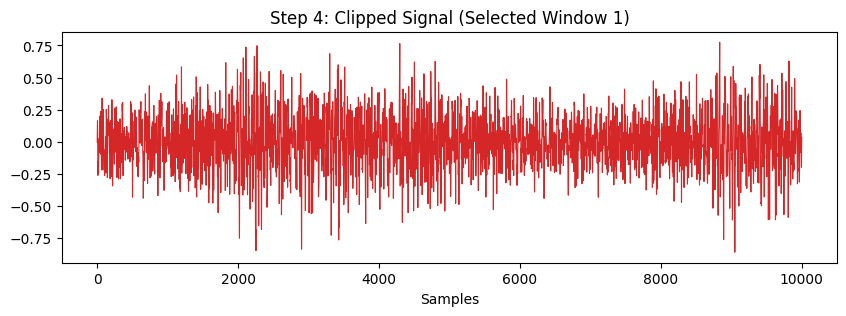

Clipped length: 50000 samples (1 second)


In [10]:
# CELL 4: Overlap Clipping
# Slices the 5-second signal into 9 overlapping 1-second windows.
# Keeps the window with the lowest variance (most stable acoustic emission).

window_size = fs           # 50,000 samples = 1 second
step_size = int(fs / 2)    # 25,000 samples = 0.5 second overlap

windows = []
# Slide across the lp_filtered signal to create 9 windows
for i in range(0, len(lp_filtered) - window_size + 1, step_size):
    windows.append(lp_filtered[i : i + window_size])

# Find the most stable window
std_devs = [np.std(w) for w in windows]
best_idx = np.argmin(std_devs)
clipped_signal = windows[best_idx]

# TEST: Plot the clipped signal. 
# Notice the X-axis is now only 50,000 samples (exactly 1 second)
plt.figure(figsize=(10, 3))
plt.plot(clipped_signal[:10000], color='#d62728', linewidth=0.8)
plt.title(f"Step 4: Clipped Signal (Selected Window {best_idx + 1})")
plt.xlabel("Samples")
plt.show()

print(f"Clipped length: {len(clipped_signal)} samples (1 second)")

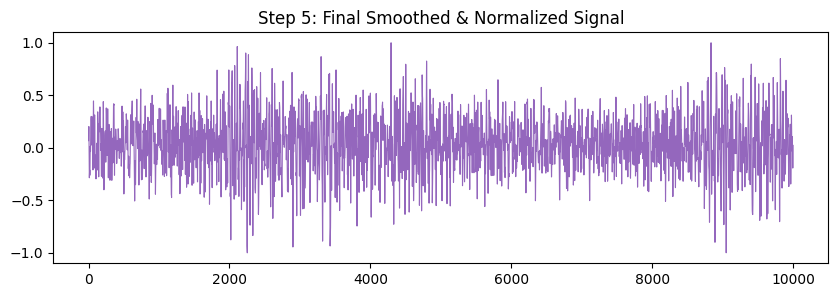

Final Range: [-1.00, 1.00]


In [11]:
# CELL 5: Smoothing and Robust Normalization
# Moving average smoothing (q=2) and percentile-based min-max scaling.

# 1. Smooth (Moving Average, 5-point window)
kernel = np.ones(5) / 5
smoothed_signal = np.convolve(clipped_signal, kernel, mode='same')

# 2. Normalize (Robust 0.025% to 99.975% percentiles as per the paper)
x_min = np.percentile(smoothed_signal, 0.025)
x_max = np.percentile(smoothed_signal, 99.975)

# Clip to bounds to remove extreme transient spikes, then scale
trimmed = np.clip(smoothed_signal, x_min, x_max)
final_signal = -1.0 + 2.0 * (trimmed - x_min) / (x_max - x_min)

# TEST: Final pre-processed waveform ready for feature extraction
plt.figure(figsize=(10, 3))
plt.plot(final_signal[:10000], color='#9467bd', linewidth=0.8)
plt.title("Step 5: Final Smoothed & Normalized Signal")
plt.show()

print(f"Final Range: [{np.min(final_signal):.2f}, {np.max(final_signal):.2f}]")

## Feature extraction

In [12]:
import os

print(os.getcwd())
print(os.listdir())

/Users/rooneysingh0027/Documents/EE656 Project - 2
['.DS_Store', 'experimentation_local.ipynb', 'svm_classifier.py', 'feature_extraction.py', 'feature_selectors.py', 'experimentation.ipynb', 'AirCompressor_Data']


In [13]:
pip install PyWavelets

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [14]:
from feature_extraction import extract_all_features

In [15]:
# CELL 6: Feature Extraction Verification (Single Signal)
# Passes the cleaned 1-second signal into our extraction module to verify 
# the 286 features (Time, FFT, MWT, DWT, WPT) generate correctly without NaNs.

import numpy as np

print("🧠 Extracting features from the 1-second preprocessed signal...")

# Extract the features as a flat mathematical vector
feature_vector, feature_names = extract_all_features(final_signal, as_vector=True)

print(f"✅ Total Features Extracted: {len(feature_vector)} (Expected: 286)")

# Sanity check: Ensure the math didn't break (no NaNs or Infs)
if np.isnan(feature_vector).any() or np.isinf(feature_vector).any():
    print("❌ ERROR: NaN or Infinity found in the feature vector!")
else:
    print("✅ Feature vector is mathematically clean.")

# Peek at the first 10 Time-Domain features
print("\n🔍 First 10 Features (Preview):")
for name, val in zip(feature_names[:30], feature_vector[:30]):
    print(f"{name:>15} : {val:.4f}")

🧠 Extracting features from the 1-second preprocessed signal...
✅ Total Features Extracted: 286 (Expected: 286)
✅ Feature vector is mathematically clean.

🔍 First 10 Features (Preview):
    td_abs_mean : 0.1951
        td_peak : 1.0000
         td_rms : 0.2521
    td_variance : 0.0622
    td_kurtosis : 3.7467
td_crest_factor : 3.9667
td_shape_factor : 1.2918
    td_skewness : -0.0150
fd_bin1_energy_ratio : 0.8484
fd_bin2_energy_ratio : 0.1497
fd_bin3_energy_ratio : 0.0019
fd_bin4_energy_ratio : 0.0000
fd_bin5_energy_ratio : 0.0000
fd_bin6_energy_ratio : 0.0000
fd_bin7_energy_ratio : 0.0000
fd_bin8_energy_ratio : 0.0000
    mwt_entropy : 14.4532
  mwt_sum_peaks : 14776.3596
        mwt_std : 7.6259
   mwt_kurtosis : 3.5181
        mwt_zcr : 0.0624
   mwt_variance : 58.1539
   mwt_skewness : -0.0055
     dwt_var_d1 : 0.0000
     dwt_var_d2 : 0.0042
     dwt_var_d3 : 0.0872
dwt_var_autocorr_d4 : 394.9989
dwt_var_autocorr_d5 : 1707.2942
dwt_var_autocorr_d6 : 410.8809
dwt_mean_smooth_d1 : 0.

## MASTER LOOP : PreProcessing & Feature Extraction

In [16]:
# CELL 7: The Grand Master Loop
# Compiles the entire 1800-file dataset into features.npy and labels.npy

import os
import time
import numpy as np
from scipy.signal import butter, sosfiltfilt, firwin, filtfilt
from feature_extraction import extract_all_features

# --- 1. Configuration ---

CLASSES = ['Healthy', 'LIV', 'LOV', 'NRV', 'Bearing', 'Piston', 'Riderbelt', 'Flywheel']
FS = 50000

# --- 2. Fast Preprocessing Function (Math Only, No Plotting) ---
def fast_preprocess(filepath):
    # Load and scale
    with open(filepath, 'r') as f:
        raw_signal = np.array([float(x) for x in f.read().split(',')], dtype=np.float32)
    
    nyq = 0.5 * FS
    
    # HPF
    fir_taps = firwin(101, 400/nyq, pass_zero=False)
    hp = filtfilt(fir_taps, [1.0], raw_signal)
    
    # LPF
    sos_lp = butter(18, 12000/nyq, btype='lowpass', output='sos')
    lp = sosfiltfilt(sos_lp, hp)
    
    # Clip
    window_size, step_size = FS, int(FS / 2)
    windows = [lp[i : i + window_size] for i in range(0, len(lp) - window_size + 1, step_size)]
    clipped = windows[np.argmin([np.std(w) for w in windows])]
    
    # Smooth & Normalize
    smoothed = np.convolve(clipped, np.ones(5)/5, mode='same')
    x_min, x_max = np.percentile(smoothed, 0.025), np.percentile(smoothed, 99.975)
    trimmed = np.clip(smoothed, x_min, x_max)
    
    if x_max > x_min:
        return -1.0 + 2.0 * (trimmed - x_min) / (x_max - x_min)
    return trimmed

# --- 3. The Extraction Loop ---
X_features = []
y_labels = []

print("🚀 Initiating Full Dataset Extraction Pipeline...")
start_time = time.time()

for label_idx, class_name in enumerate(CLASSES):
    folder_path = os.path.join(DATA_DIR, class_name)
    if not os.path.exists(folder_path):
        print(f"⚠ Skipping {class_name}, folder not found.")
        continue
        
    files = [f for f in os.listdir(folder_path) if f.endswith('.dat')]
    print(f"\n⚙️ Processing {class_name.upper()} ({len(files)} files)...")
    
    for i, file in enumerate(files):
        filepath = os.path.join(folder_path, file)
        
        try:
            # Preprocess
            clean_sig = fast_preprocess(filepath)
            
            # Extract
            feature_vector, _ = extract_all_features(clean_sig, as_vector=True)
            
            # Store
            X_features.append(feature_vector)
            y_labels.append(label_idx) # Save as numeric label (0 to 7)
            
        except Exception as e:
            print(f"Error on {file}: {e}")
            
        # Progress Tracker
        if (i + 1) % 45 == 0:
            print(f"   [{i + 1:3d}/{len(files)}] files processed")

# --- 4. Final Compilation ---
X = np.array(X_features, dtype=float)
y = np.array(y_labels, dtype=int)

print("\n📦 Matrix Compilation Complete!")
print(f"Feature Matrix Shape (X): {X.shape}") 
print(f"Label Vector Shape   (y): {y.shape}")   

np.save('features.npy', X)
np.save('labels.npy', y)

elapsed = (time.time() - start_time) / 60
print(f"✅ SUCCESS! Extracted data saved to disk in {elapsed:.2f} minutes.")

🚀 Initiating Full Dataset Extraction Pipeline...

⚙️ Processing HEALTHY (225 files)...
   [ 45/225] files processed
   [ 90/225] files processed
   [135/225] files processed
   [180/225] files processed
   [225/225] files processed

⚙️ Processing LIV (225 files)...
   [ 45/225] files processed
   [ 90/225] files processed
   [135/225] files processed
   [180/225] files processed
   [225/225] files processed

⚙️ Processing LOV (225 files)...
   [ 45/225] files processed
   [ 90/225] files processed
   [135/225] files processed
   [180/225] files processed
   [225/225] files processed

⚙️ Processing NRV (225 files)...
   [ 45/225] files processed
   [ 90/225] files processed
   [135/225] files processed
   [180/225] files processed
   [225/225] files processed

⚙️ Processing BEARING (225 files)...
   [ 45/225] files processed
   [ 90/225] files processed
   [135/225] files processed
   [180/225] files processed
   [225/225] files processed

⚙️ Processing PISTON (225 files)...
   [ 45/225

## Feature selection

mRMR + DDAG

In [22]:
pip install mrmr-selection

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 82 kB 129 kB/s eta 0:00:01
     |████████████████████████████████| 802 kB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 39.3 MB 5.0 MB/s eta 0:00:01
     |████████████████████████████████| 10.0 MB 28.0 MB/s eta 0:00:01
     |████████████████████████████████| 233 kB 29.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


📂 Loading Extracted Features...

🚀 Initiating mRMR Feature Selection Test (k=3 folds)...

⚙️ Testing top 5 features...


100%|██████████| 5/5 [00:00<00:00, 23.78it/s]


✅ 5 Features -> Mean Accuracy: 84.78%

⚙️ Testing top 10 features...


100%|██████████| 10/10 [00:00<00:00, 30.37it/s]


✅ 10 Features -> Mean Accuracy: 96.00%

⚙️ Testing top 15 features...


...

✅ 50 Features -> Mean Accuracy: 98.83%

⚙️ Testing top 100 features...


100%|██████████| 100/100 [00:03<00:00, 26.78it/s]


✅ 100 Features -> Mean Accuracy: 98.94%

⚙️ Testing top 286 features...


100%|██████████| 285/285 [00:12<00:00, 22.89it/s]


✅ 286 Features -> Mean Accuracy: 99.06%

⏱️ Experiment completed in 33.30 minutes.


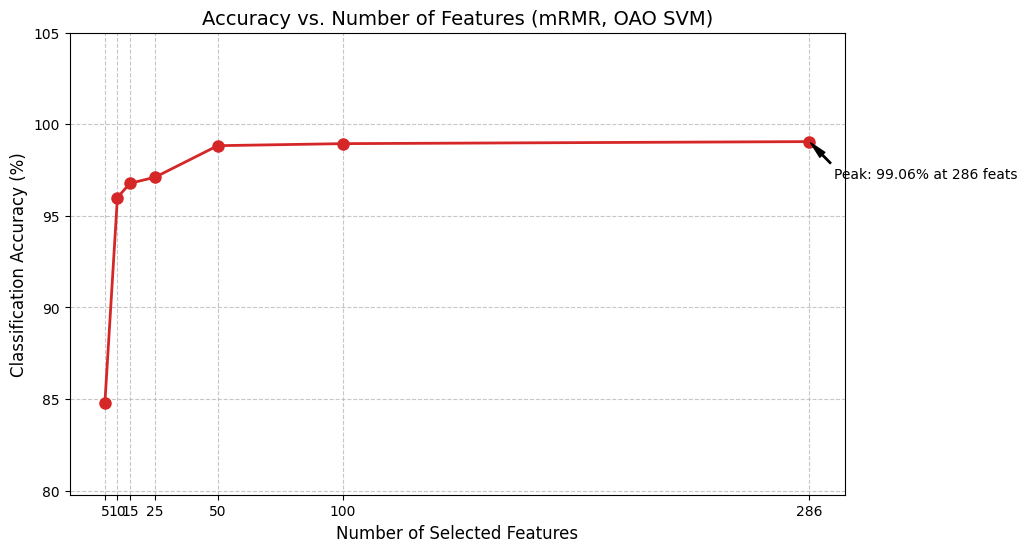

In [ ]:
# CELL 8: Phase 4 - Feature Selection (mRMR Accuracy Curve)
# Fixed: Added StandardScaler to prevent RBF Kernel distance dominance

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler # <-- THE FIX
import pandas as pd
from mrmr import mrmr_classif

from feature_selectors import get_selector
from svm_classifier import SVMFaultClassifier, grid_search_svm

# 1. Load the matrices
print("📂 Loading Extracted Features...")
X = np.load('features.npy')
y = np.load('labels.npy')

# 2. Configuration for the test
n_features_list = [5, 10, 15, 25, 50, 100, 286]
method = 'mRMR'
k_fold = 3  
decomposition = 'DDAG'

mean_accuracies = []

print(f"\n🚀 Initiating {method} Feature Selection Test (k={k_fold} folds)...")
start_time = time.time()

for n_feat in n_features_list:
    print(f"\n⚙️ Testing top {n_feat} features...")
    
    skf = StratifiedKFold(n_splits=k_fold, shuffle=True, random_state=42)
    fold_accs = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # --- THE FIX: LIBSVM Equivalent Min-Max Scaling ---
        # Scale all features to [-1, 1] to prevent WPT energy values from 
        # blowing up the RBF kernel distance metric.
        scaler = MinMaxScaler(feature_range=(-1, 1))
        # X_train = scaler.fit_transform(X_train)
        # X_test = scaler.transform(X_test)


        # --- A1. Feature Selection ---
        # selector = get_selector(method, min(n_feat, 286))
        # X_train_sel, X_test_sel = selector.fit_transform_data(X_train, X_test, y_train)

        # --- A2. Feature Scaling ---
        # X_train_sel = scaler.fit_transform(X_train_sel)
        # X_test_sel = scaler.transform(X_test_sel)

        # Inside your fold loop, replace the selector block with:
        X_train_df = pd.DataFrame(X_train)
        selected_features = mrmr_classif(X_train_df, pd.Series(y_train), K=n_feat)

        X_train_sel = X_train[:, selected_features]
        X_test_sel = X_test[:, selected_features]

        # Then scale
        X_train_sel = scaler.fit_transform(X_train_sel)
        X_test_sel = scaler.transform(X_test_sel)


        # --- B. Hyperparameter Grid Search ---
        best_C, best_gamma, _ = grid_search_svm(
            X_train_sel, y_train, decomposition=decomposition, cv=3
        )
        
        # --- C. Train and Evaluate Final Model ---
        clf = SVMFaultClassifier(decomposition=decomposition, C=best_C, gamma=best_gamma)
        clf.fit(X_train_sel, y_train)
        
        acc = clf.accuracy(X_test_sel, y_test)
        fold_accs.append(acc)
        
    mean_acc = np.mean(fold_accs)
    mean_accuracies.append(mean_acc)
    print(f"✅ {n_feat} Features -> Mean Accuracy: {mean_acc:.2f}%")

elapsed = (time.time() - start_time) / 60
print(f"\n⏱️ Experiment completed in {elapsed:.2f} minutes.")

# 3. Plotting the Results
plt.figure(figsize=(10, 6))
plt.plot(n_features_list, mean_accuracies, marker='o', linestyle='-', color='#d62728', linewidth=2, markersize=8)

plt.title(f"Accuracy vs. Number of Features ({method}, {decomposition} SVM)", fontsize=14)
plt.xlabel("Number of Selected Features", fontsize=12)
plt.ylabel("Classification Accuracy (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(n_features_list)
plt.ylim(max(0, min(mean_accuracies) - 5), 105)

max_acc = max(mean_accuracies)
best_n = n_features_list[mean_accuracies.index(max_acc)]
plt.annotate(f'Peak: {max_acc:.2f}% at {best_n} feats', 
             xy=(best_n, max_acc), xytext=(best_n + 10, max_acc - 2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.show()

In [21]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

print("📂 Loading features...")
X = np.load('features.npy')
y = np.load('labels.npy')

print("🌲 Running 5-Second XGBoost Test...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
scores = cross_val_score(rf, X, y, cv=3)

print(f"✅ Random Forest Baseline Accuracy: {np.mean(scores) * 100:.2f}%")

📂 Loading features...
🌲 Running 5-Second XGBoost Test...
✅ Random Forest Baseline Accuracy: 96.78%


In [ ]:
import numpy as np
import pickle

mrmr_ddag_3fold = {
    'n_features': [5, 10, 15, 25, 50, 100, 286],
    'accuracies': [84.78, 96.00, 96.78, 97.11, 98.83, 98.94, 99.06],
    'method': 'mRMR',
    'decomposition': 'DDAG',
    'k_fold': 3,
    'time_elapsed_minutes': 33.30
}

with open('results_mrmr_ddag_3fold.pkl', 'wb') as f:
    pickle.dump(mrmr_ddag_3fold, f)

print("✅ Saved.")

✅ Saved.


# OVERNIGHT EXPERIMENTS

In [60]:
# OVERNIGHT RUN: All 6 Feature Selectors × 7 Feature Counts × 3 Folds
# Runtime estimate: 3-5 hours depending on BD and MIFS

import numpy as np
import pandas as pd
import pickle
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from mrmr import mrmr_classif
from feature_selectors import get_selector
from svm_classifier import SVMFaultClassifier, grid_search_svm

# ── Load Data ──────────────────────────────────────────────
X = np.load('features.npy')
y = np.load('labels.npy')

# ── Config ─────────────────────────────────────────────────
n_features_list = [5, 10, 15, 25, 50, 100, 150, 200, 286]
k_fold          = 3
decomposition   = 'DDAG'
METHODS         = ['PCA', 'MIFS', 'NMIFS', 'mRMR', 'MIFS-U', 'BD']

# Already measured — skip recomputing for all methods at 286
# CACHED_286 = 99.06

# ── Main Loop ──────────────────────────────────────────────
all_results = {}

for method in METHODS:
    print(f"\n{'='*55}")
    print(f"  METHOD: {method}")
    print(f"{'='*55}")

    method_accs = []
    method_start = time.time()

    for n_feat in n_features_list:

        # ── Skip 286: use cached result, no selector needed ──
        if n_feat == 286:
            # ── Scale ─────────────────────────────────────────
            scaler      = MinMaxScaler(feature_range=(-1, 1))
            X_train_sel = scaler.fit_transform(X_train_sel)
            X_test_sel  = scaler.transform(X_test_sel)

            # ── Grid Search ───────────────────────────────────
            best_C, best_gamma, _ = grid_search_svm(
                X_train_sel, y_train,
                decomposition=decomposition,
                cv=3
            )

            # ── Train + Evaluate ──────────────────────────────
            clf = SVMFaultClassifier(decomposition, best_C, best_gamma)
            clf.fit(X_train_sel, y_train)
            fold_accs.append(clf.accuracy(X_test_sel, y_test))

            mean_acc = np.mean(fold_accs)
            method_accs.append(mean_acc)
            print(f"  ✅ {n_feat:>3} features → {mean_acc:.2f}%")

            continue

        print(f"\n  ⚙️  Testing {n_feat} features...")
        skf       = StratifiedKFold(n_splits=k_fold, shuffle=True, random_state=42)
        fold_accs = []

        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # ── Feature Selection ─────────────────────────────
            if method == 'mRMR':
                selected    = mrmr_classif(
                                pd.DataFrame(X_train),
                                pd.Series(y_train),
                                K=n_feat,
                                show_progress=False
                              )
                X_train_sel = X_train[:, selected]
                X_test_sel  = X_test[:,  selected]

            else:
                selector = get_selector(method, min(n_feat, 286))
                X_train_sel, X_test_sel = selector.fit_transform_data(
                    X_train, X_test, y_train
                )

            # ── Scale ─────────────────────────────────────────
            scaler      = MinMaxScaler(feature_range=(-1, 1))
            X_train_sel = scaler.fit_transform(X_train_sel)
            X_test_sel  = scaler.transform(X_test_sel)

            # ── Grid Search ───────────────────────────────────
            best_C, best_gamma, _ = grid_search_svm(
                X_train_sel, y_train,
                decomposition=decomposition,
                cv=3
            )

            # ── Train + Evaluate ──────────────────────────────
            clf = SVMFaultClassifier(decomposition, best_C, best_gamma)
            clf.fit(X_train_sel, y_train)
            fold_accs.append(clf.accuracy(X_test_sel, y_test))

        mean_acc = np.mean(fold_accs)
        method_accs.append(mean_acc)
        print(f"  ✅ {n_feat:>3} features → {mean_acc:.2f}%")

    # ── Save checkpoint after every method ───────────────────
    all_results[method] = method_accs
    elapsed = (time.time() - method_start) / 60
    print(f"\n  ⏱️  {method} completed in {elapsed:.1f} min")

    with open('all_selector_results2.pkl', 'wb') as f:
        pickle.dump(all_results, f)
    print(f"  💾 Checkpoint saved → all_selector_results2.pkl")

# ── Done ───────────────────────────────────────────────────
print("\n\n🎉 ALL EXPERIMENTS COMPLETE.")
print("Results saved to: all_selector_results2.pkl")

# ── Quick Summary Table ────────────────────────────────────
print(f"\n{'Method':<10}", end="")
for n in n_features_list:
    print(f"{n:>8}", end="")
print()
print("-" * 70)
for method in METHODS:
    print(f"{method:<10}", end="")
    for acc in all_results[method]:
        print(f"{acc:>8.2f}", end="")
    print()


  METHOD: PCA

  ⚙️  Testing 5 features...


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [42]:
pip install tabulate

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


📂 Loading overnight results...

📊 PUBLICATION SUMMARY TABLE (Accuracy %):
| Method   |     5 |    10 |    15 |    25 |    50 |   100 |   286 |
|:---------|------:|------:|------:|------:|------:|------:|------:|
| PCA      | 72.67 | 90.11 | 93.94 | 98.22 | 98.83 | 98.22 | 99.06 |
| MIFS     | 49.67 | 52.83 | 61.78 | 77.44 | 91.00 | 96.83 | 99.06 |
| NMIFS    | 50.28 | 66.33 | 74.83 | 90.83 | 95.94 | 97.83 | 99.06 |
| mRMR     | 84.78 | 96.00 | 96.78 | 97.11 | 98.83 | 98.94 | 99.06 |
| MIFS-U   | 49.72 | 53.39 | 63.06 | 76.11 | 92.17 | 96.78 | 99.06 |
| BD       | 73.83 | 83.61 | 89.72 | 94.22 | 97.39 | 98.44 | 99.06 |

💾 Table saved to 'feature_selection_summary.csv'
📸 High-resolution plot saved to 'feature_selection_comparison_300dpi.png'


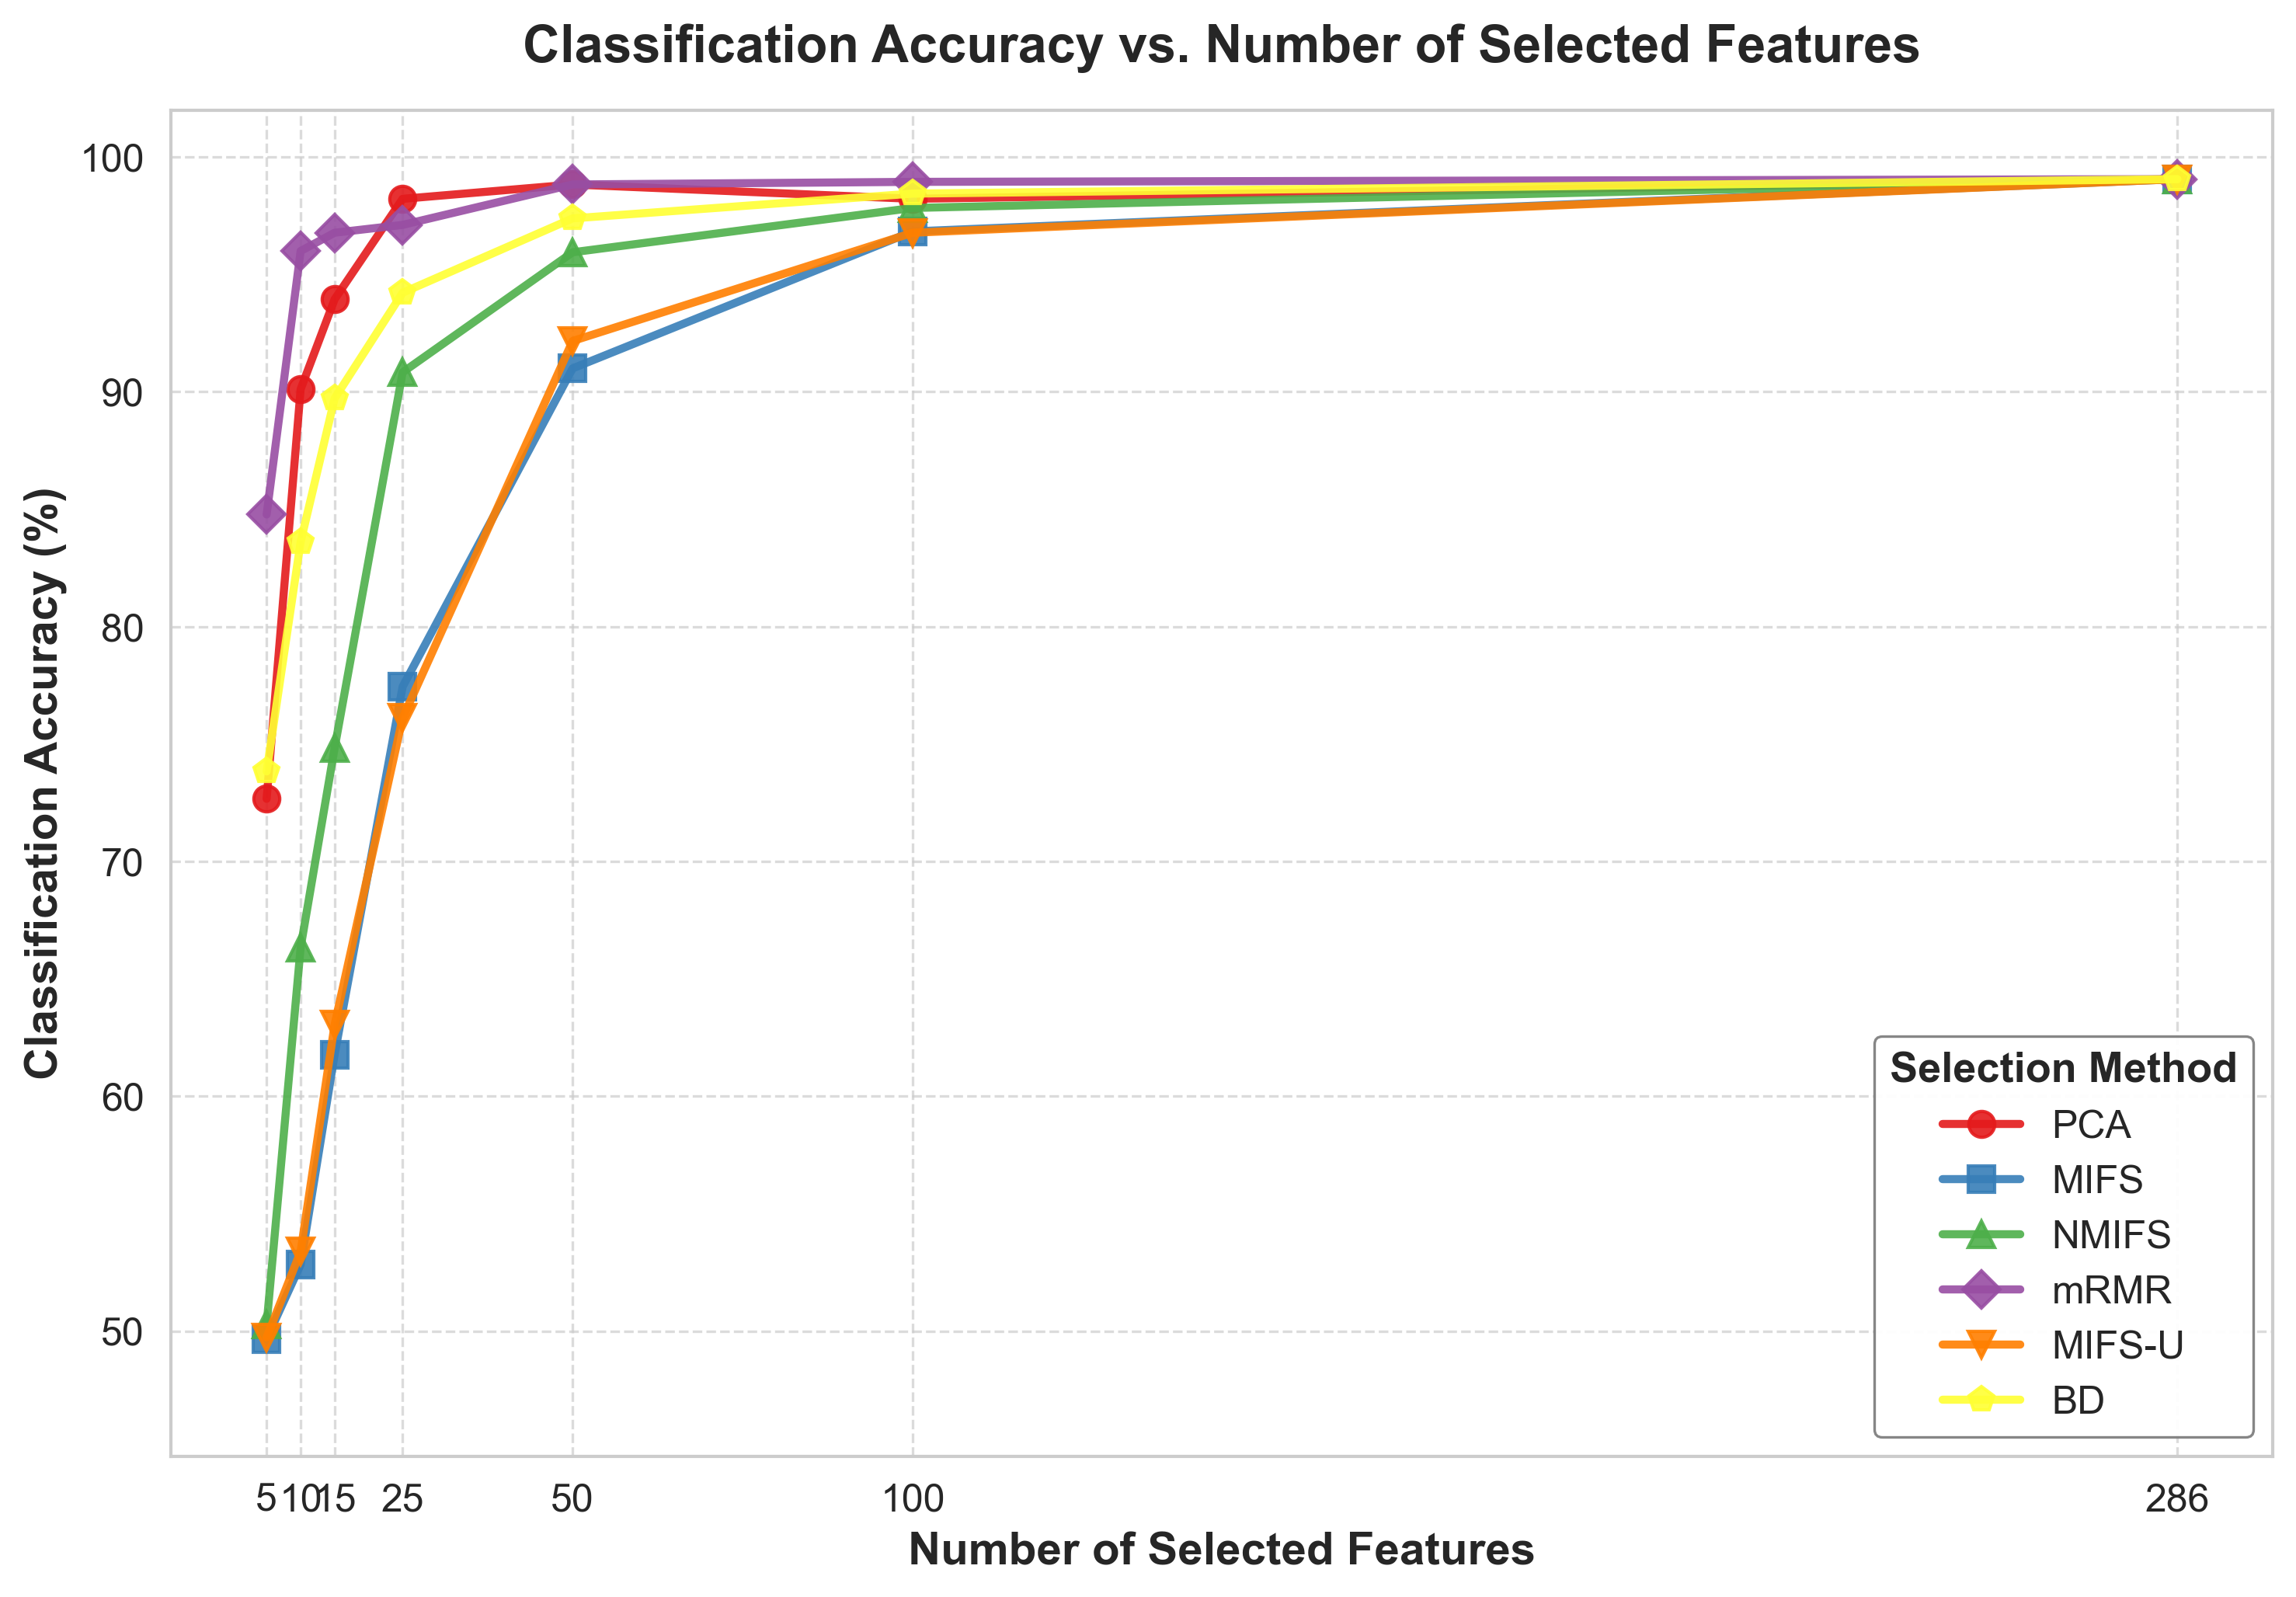

In [43]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────────────────
# 1. LOAD THE DATA
# ─────────────────────────────────────────────────────────
print("📂 Loading overnight results...")
with open('all_selector_results.pkl', 'rb') as f:
    results = pickle.load(f)

n_features = [5, 10, 15, 25, 50, 100, 286]
methods = ['PCA', 'MIFS', 'NMIFS', 'mRMR', 'MIFS-U', 'BD']

# ─────────────────────────────────────────────────────────
# 2. GENERATE PUBLICATION-READY TABLE
# ─────────────────────────────────────────────────────────
# Convert the dictionary into a Pandas DataFrame for a beautiful layout
df = pd.DataFrame(results, index=n_features).T
df.columns.name = "Features"
df.index.name = "Method"

print("\n📊 PUBLICATION SUMMARY TABLE (Accuracy %):")
# to_markdown() formats it perfectly for GitHub, Notion, or copying into reports
print(df.to_markdown(floatfmt=".2f"))

# Optional: Save to CSV for Excel/LaTeX import
df.to_csv("feature_selection_summary.csv")
print("\n💾 Table saved to 'feature_selection_summary.csv'")

# ─────────────────────────────────────────────────────────
# 3. GENERATE HIGH-RES PUBLICATION PLOT
# ─────────────────────────────────────────────────────────
# Set a clean, academic theme
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Create figure with high DPI (300 is standard for IEEE/academic journals)
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

# Distinct markers and colorblind-friendly colors (Set1)
markers = ['o', 's', '^', 'D', 'v', 'p']
colors = sns.color_palette("Set1", n_colors=len(methods))

# Plot each method
for idx, method in enumerate(methods):
    ax.plot(
        n_features, 
        results[method], 
        marker=markers[idx],
        linewidth=2.5, 
        markersize=8, 
        label=method, 
        color=colors[idx],
        alpha=0.9
    )

# ── Aesthetics & Formatting ──
ax.set_title("Classification Accuracy vs. Number of Selected Features", 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Number of Selected Features", fontsize=14, fontweight='bold')
ax.set_ylabel("Classification Accuracy (%)", fontsize=14, fontweight='bold')

# Ensure the x-axis ticks match our exact feature steps
ax.set_xticks(n_features)
ax.set_xticklabels(n_features, fontsize=12)
ax.tick_params(axis='y', labelsize=12)

# Dynamically scale the y-axis to focus on the action
all_accs = [acc for method_accs in results.values() for acc in method_accs]
y_min = max(0, min(all_accs) - 5)
ax.set_ylim(y_min, 102)

# Customize the grid to be unobtrusive
ax.grid(True, linestyle='--', alpha=0.7)

# Format the legend beautifully
legend = ax.legend(
    title="Selection Method", 
    title_fontsize='13', 
    fontsize='12', 
    loc='lower right', 
    framealpha=0.95,
    edgecolor='gray'
)
legend.get_title().set_fontweight('bold')

# ── Save and Show ──
plt.tight_layout()
plot_filename = 'feature_selection_comparison_300dpi.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"📸 High-resolution plot saved to '{plot_filename}'")

plt.show()

In [58]:
# ═══════════════════════════════════════════════════════════
# EXPERIMENT 2: mRMR only, k ∈ {2, 3, 5, 10} Folds
# Output: exp2_fold_results.pkl
# Runtime: ~2 hours
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import pickle
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from mrmr import mrmr_classif
from svm_classifier import SVMFaultClassifier, grid_search_svm

X = np.load('features.npy')
y = np.load('labels.npy')

n_features_list = [5, 10, 15, 25, 50, 100, 286]
k_folds         = [2, 3, 5, 10]
decomposition   = 'DDAG'

fold_results = {}   # k -> list of accuracies
fold_times   = {}   # k -> list of times

for k_fold in k_folds:
    print(f"\n{'='*55}")
    print(f"  k = {k_fold} FOLD")
    print(f"{'='*55}")

    fold_accs_list  = []
    fold_times_list = []
    k_start         = time.time()

    for n_feat in n_features_list:

        print(f"\n  ⚙️  {n_feat} features...")
        feat_start = time.time()
        skf        = StratifiedKFold(n_splits=k_fold, shuffle=True, random_state=42)
        accs       = []

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            selected    = mrmr_classif(
                            pd.DataFrame(X_train), pd.Series(y_train),
                            K=n_feat, show_progress=False, n_jobs=1)
            X_train_sel = X_train[:, selected]
            X_test_sel  = X_test[:,  selected]

            scaler      = MinMaxScaler(feature_range=(-1, 1))
            X_train_sel = scaler.fit_transform(X_train_sel)
            X_test_sel  = scaler.transform(X_test_sel)

            best_C, best_gamma, _ = grid_search_svm(
                X_train_sel, y_train, decomposition=decomposition, cv=3)

            clf = SVMFaultClassifier(decomposition, best_C, best_gamma)
            clf.fit(X_train_sel, y_train)
            accs.append(clf.accuracy(X_test_sel, y_test))

        mean_acc  = np.mean(accs)
        feat_time = (time.time() - feat_start) / 60
        fold_accs_list.append(mean_acc)
        fold_times_list.append(feat_time)
        print(f"  ✅ {n_feat:>3} features → {mean_acc:.2f}%  ({feat_time:.1f} min)")

    fold_results[k_fold] = fold_accs_list
    fold_times[k_fold]   = fold_times_list
    k_elapsed = (time.time() - k_start) / 60
    print(f"\n  ⏱️  k={k_fold} done in {k_elapsed:.1f} min")

    with open('exp2_fold_results.pkl', 'wb') as f:
        pickle.dump({'accuracies': fold_results, 'times': fold_times}, f)
    print(f"  💾 Checkpoint saved.")

# Summary table
print(f"\n\n{'k-Fold':<10}", end="")
for n in n_features_list:
    print(f"{n:>8}", end="")
print()
print("-" * 70)
for k in k_folds:
    print(f"k={k:<8}", end="")
    for acc in fold_results[k]:
        print(f"{acc:>8.2f}", end="")
    print()

print("\n🎉 EXPERIMENT 2 COMPLETE.")


  k = 2 FOLD

  ⚙️  5 features...


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
# ═══════════════════════════════════════════════════════════
# EXPERIMENT 3: OAO vs OAA vs DDAG, mRMR, k=3 Fold
# Output: exp3_decomp_results.pkl
# Runtime: ~2 hours (OAA is slowest)
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import pickle
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from mrmr import mrmr_classif
from svm_classifier import SVMFaultClassifier, grid_search_svm

X = np.load('features.npy')
y = np.load('labels.npy')

n_features_list = [5, 10, 15, 25, 50, 100, 286]
decompositions  = ['OAO', 'OAA', 'DDAG']
k_fold          = 3
CACHED_286      = 99.06

decomp_results = {}   # decomp -> list of accuracies
decomp_times   = {}   # decomp -> list of times

for decomposition in decompositions:
    print(f"\n{'='*55}")
    print(f"  DECOMPOSITION: {decomposition}")
    print(f"{'='*55}")

    decomp_accs  = []
    decomp_t     = []
    decomp_start = time.time()

    for n_feat in n_features_list:

        if n_feat == 286:
            decomp_accs.append(CACHED_286)
            decomp_t.append(0.0)
            print(f"  ✅ 286 features → {CACHED_286:.2f}%  (cached)")
            continue

        print(f"\n  ⚙️  {n_feat} features...")
        feat_start = time.time()
        skf        = StratifiedKFold(n_splits=k_fold, shuffle=True, random_state=42)
        accs       = []

        for train_idx, test_idx in skf.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            selected    = mrmr_classif(
                            pd.DataFrame(X_train), pd.Series(y_train),
                            K=n_feat, show_progress=False, n_jobs=-1)
            X_train_sel = X_train[:, selected]
            X_test_sel  = X_test[:,  selected]

            scaler      = MinMaxScaler(feature_range=(-1, 1))
            X_train_sel = scaler.fit_transform(X_train_sel)
            X_test_sel  = scaler.transform(X_test_sel)

            best_C, best_gamma, _ = grid_search_svm(
                X_train_sel, y_train,
                decomposition=decomposition, cv=3)

            clf = SVMFaultClassifier(decomposition, best_C, best_gamma)
            clf.fit(X_train_sel, y_train)
            accs.append(clf.accuracy(X_test_sel, y_test))

        mean_acc  = np.mean(accs)
        feat_time = (time.time() - feat_start) / 60
        decomp_accs.append(mean_acc)
        decomp_t.append(feat_time)
        print(f"  ✅ {n_feat:>3} features → {mean_acc:.2f}%  ({feat_time:.1f} min)")

    decomp_results[decomposition] = decomp_accs
    decomp_times[decomposition]   = decomp_t
    total = (time.time() - decomp_start) / 60
    print(f"\n  ⏱️  {decomposition} done in {total:.1f} min")

    with open('exp3_decomp_results.pkl', 'wb') as f:
        pickle.dump({'accuracies': decomp_results, 'times': decomp_times}, f)
    print(f"  💾 Checkpoint saved.")

# Summary table
print(f"\n\n{'Decomp':<10}", end="")
for n in n_features_list:
    print(f"{n:>8}", end="")
print()
print("-" * 70)
for d in decompositions:
    print(f"{d:<10}", end="")
    for acc in decomp_results[d]:
        print(f"{acc:>8.2f}", end="")
    print()

print("\n🎉 EXPERIMENT 3 COMPLETE.")


  DECOMPOSITION: OAO

  ⚙️  5 features...
  ✅   5 features → 84.78%  (1.3 min)

  ⚙️  10 features...
  ✅  10 features → 96.00%  (1.1 min)

  ⚙️  15 features...
  ✅  15 features → 96.78%  (1.2 min)

  ⚙️  25 features...
  ✅  25 features → 97.11%  (2.1 min)

  ⚙️  50 features...
  ✅  50 features → 98.83%  (2.7 min)

  ⚙️  100 features...
  ✅ 100 features → 98.94%  (8.0 min)
  ✅ 286 features → 99.06%  (cached)

  ⏱️  OAO done in 16.4 min
  💾 Checkpoint saved.

  DECOMPOSITION: OAA

  ⚙️  5 features...
  ✅   5 features → 84.78%  (0.8 min)

  ⚙️  10 features...
  ✅  10 features → 96.11%  (0.8 min)

  ⚙️  15 features...
  ✅  15 features → 97.11%  (1.0 min)

  ⚙️  25 features...
  ✅  25 features → 98.50%  (1.4 min)

  ⚙️  50 features...
  ✅  50 features → 99.22%  (1.8 min)

  ⚙️  100 features...
  ✅ 100 features → 99.17%  (5.5 min)
  ✅ 286 features → 99.06%  (cached)

  ⏱️  OAA done in 11.4 min
  💾 Checkpoint saved.

  DECOMPOSITION: DDAG

  ⚙️  5 features...
  ✅   5 features → 84.61%  (0.4 

In [27]:
# ═══════════════════════════════════════════════════════════
# EXPERIMENT 4: Feature Domain Contribution after mRMR
# Reproduces Table VIII from the paper
# Output: exp4_feature_domains.pkl + printed table
# Runtime: ~20 minutes
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import StratifiedKFold
from mrmr import mrmr_classif

X = np.load('features.npy')
y = np.load('labels.npy')

# ── Feature index ranges (must match your feature_extraction.py order) ──
# TD:  0-7    (8 features)
# FFT: 8-15   (8 features)
# MWT: 16-22  (7 features)
# DWT: 23-31  (9 features)
# WPT: 32-285 (254 features)

DOMAIN_RANGES = {
    'TD':  (0,   8),
    'FFT': (8,   16),
    'MWT': (16,  23),
    'DWT': (23,  32),
    'WPT': (32,  286),
}

def get_domain(feature_idx):
    for domain, (start, end) in DOMAIN_RANGES.items():
        if start <= feature_idx < end:
            return domain
    return 'Unknown'

# ── Config ──────────────────────────────────────────────────
n_features_list = [5, 10, 15, 25, 50, 75, 100, 286]
k_fold          = 3

# ── Main Loop ───────────────────────────────────────────────
# For each n_feat: run k folds, collect selected feature indices,
# average domain counts across folds

domain_table = {}   # n_feat -> {domain -> avg count}

for n_feat in n_features_list:

    if n_feat == 286:
        # All features selected — counts are fixed
        domain_table[286] = {
            'TD': 8, 'FFT': 8, 'MWT': 7, 'DWT': 9, 'WPT': 254
        }
        print(f"✅ 286 features → fixed (all selected)")
        continue

    print(f"\n⚙️  Running mRMR for {n_feat} features...")
    skf = StratifiedKFold(n_splits=k_fold, shuffle=True, random_state=42)

    fold_domain_counts = []

    for fold_idx, (train_idx, _) in enumerate(skf.split(X, y)):
        X_train = X[train_idx]
        y_train = y[train_idx]

        selected = mrmr_classif(
            pd.DataFrame(X_train),
            pd.Series(y_train),
            K=n_feat,
            show_progress=False
        )

        # Count how many selected features came from each domain
        counts = {d: 0 for d in DOMAIN_RANGES}
        for idx in selected:
            counts[get_domain(idx)] += 1

        fold_domain_counts.append(counts)

    # Average across folds and round to nearest int
    avg_counts = {}
    for domain in DOMAIN_RANGES:
        avg_counts[domain] = int(round(
            np.mean([fc[domain] for fc in fold_domain_counts])
        ))

    domain_table[n_feat] = avg_counts

    # Verify counts sum to n_feat
    total = sum(avg_counts.values())
    print(f"✅ {n_feat} features → {avg_counts}  (sum={total})")

# ── Save ────────────────────────────────────────────────────
with open('exp4_feature_domains.pkl', 'wb') as f:
    pickle.dump(domain_table, f)
print("\n💾 Saved → exp4_feature_domains.pkl")

# ── Print Table VIII equivalent ─────────────────────────────
print("\n")
print("=" * 55)
print("  TABLE VIII EQUIVALENT — mRMR Feature Domain Contribution")
print("=" * 55)
print(f"{'No. of':>10}  {'TD':>6}  {'FFT':>6}  {'MWT':>6}  {'DWT':>6}  {'WPT':>6}")
print(f"{'Features':>10}  {'':>6}  {'':>6}  {'':>6}  {'':>6}  {'':>6}")
print("-" * 55)
for n_feat in n_features_list:
    row = domain_table[n_feat]
    print(f"{n_feat:>10}  {row['TD']:>6}  {row['FFT']:>6}  {row['MWT']:>6}  {row['DWT']:>6}  {row['WPT']:>6}")
print("=" * 55)

print("\n🎉 EXPERIMENT 4 COMPLETE.")


⚙️  Running mRMR for 5 features...
✅ 5 features → {'TD': 0, 'FFT': 1, 'MWT': 1, 'DWT': 0, 'WPT': 3}  (sum=5)

⚙️  Running mRMR for 10 features...
✅ 10 features → {'TD': 0, 'FFT': 1, 'MWT': 1, 'DWT': 0, 'WPT': 8}  (sum=10)

⚙️  Running mRMR for 15 features...
✅ 15 features → {'TD': 0, 'FFT': 1, 'MWT': 1, 'DWT': 0, 'WPT': 13}  (sum=15)

⚙️  Running mRMR for 25 features...
✅ 25 features → {'TD': 0, 'FFT': 1, 'MWT': 1, 'DWT': 0, 'WPT': 23}  (sum=25)

⚙️  Running mRMR for 50 features...
✅ 50 features → {'TD': 0, 'FFT': 1, 'MWT': 2, 'DWT': 0, 'WPT': 47}  (sum=50)

⚙️  Running mRMR for 75 features...
✅ 75 features → {'TD': 0, 'FFT': 1, 'MWT': 4, 'DWT': 0, 'WPT': 70}  (sum=75)

⚙️  Running mRMR for 100 features...
✅ 100 features → {'TD': 1, 'FFT': 2, 'MWT': 5, 'DWT': 2, 'WPT': 90}  (sum=100)
✅ 286 features → fixed (all selected)

💾 Saved → exp4_feature_domains.pkl


  TABLE VIII EQUIVALENT — mRMR Feature Domain Contribution
    No. of      TD     FFT     MWT     DWT     WPT
  Features        

### PLOT RESULTS FOR THE THREE EXPERIMENTS

In [ ]:
# ═══════════════════════════════════════════════
# PLOTTING: Load all results and generate figures
# ═══════════════════════════════════════════════

import numpy as np
import pickle
import matplotlib.pyplot as plt

n_features_list = [5, 10, 15, 25, 50, 100, 286]

# ── Plot 1: All 6 Selectors ──────────────────────
with open('exp1_selector_results.pkl', 'rb') as f:
    exp1 = pickle.load(f)

colors = ['#d62728','#1f77b4','#2ca02c','#ff7f0e','#9467bd','#8c564b']
plt.figure(figsize=(10, 6))
for i, (method, accs) in enumerate(exp1['accuracies'].items()):
    plt.plot(n_features_list, accs, marker='o', label=method,
             color=colors[i], linewidth=2, markersize=7)
plt.title("Accuracy vs. Features — All Selectors (DDAG SVM, k=3)", fontsize=13)
plt.xlabel("Number of Selected Features")
plt.ylabel("Classification Accuracy (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(60, 102)
plt.tight_layout()
plt.savefig('plot_exp1_selectors.png', dpi=150)
plt.show()

# ── Plot 2: Different Folds ───────────────────────
with open('exp2_fold_results.pkl', 'rb') as f:
    exp2 = pickle.load(f)

colors2 = ['#d62728','#1f77b4','#2ca02c','#ff7f0e']
plt.figure(figsize=(10, 6))
for i, (k, accs) in enumerate(exp2['accuracies'].items()):
    plt.plot(n_features_list, accs, marker='o', label=f'k={k}',
             color=colors2[i], linewidth=2, markersize=7)
plt.title("Accuracy vs. Features — mRMR, Different k-Folds", fontsize=13)
plt.xlabel("Number of Selected Features")
plt.ylabel("Classification Accuracy (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(60, 102)
plt.tight_layout()
plt.savefig('plot_exp2_folds.png', dpi=150)
plt.show()

# ── Plot 3: OAO vs OAA vs DDAG ───────────────────
with open('exp3_decomp_results.pkl', 'rb') as f:
    exp3 = pickle.load(f)

colors3 = ['#d62728','#1f77b4','#2ca02c']
plt.figure(figsize=(10, 6))
for i, (d, accs) in enumerate(exp3['accuracies'].items()):
    plt.plot(n_features_list, accs, marker='o', label=d,
             color=colors3[i], linewidth=2, markersize=7)
plt.title("Accuracy vs. Features — mRMR, OAO vs OAA vs DDAG", fontsize=13)
plt.xlabel("Number of Selected Features")
plt.ylabel("Classification Accuracy (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(60, 102)
plt.tight_layout()
plt.savefig('plot_exp3_decomp.png', dpi=150)
plt.show()

print("✅ All 3 plots saved.")

# Final model params

In [31]:
# ─────────────────────────────────────────────────────────
# OPTIMIZED SVM Grid Search — Inverted Loops & Cached mRMR
# ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
import time
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from mrmr import mrmr_classif
from svm_classifier import SVMFaultClassifier, grid_search_svm

X = np.load('features.npy')
y = np.load('labels.npy')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

n_features_list = [5, 10, 15, 25, 50, 100, 286]
decomposition = 'OAO'
inner_cv_folds = 5

# Dictionary to hold fold tracking metrics: {n_feat: [fold_1_acc, fold_2_acc, ...]}
results_tracker = {n: {'accs': [], 'Cs': [], 'gammas': []} for n in n_features_list}

print("🚀 Starting optimized loop (Outer Fold -> Inner Features)...")
start = time.time()

skf = StratifiedKFold(n_splits=inner_cv_folds, shuffle=True, random_state=42)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    fold_start = time.time()
    print(f"\n📁 Processing Outer Fold {fold_idx + 1}/{inner_cv_folds}...")
    
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    # COMPUTE mRMR ONLY ONCE PER FOLD FOR THE MAX REQUIRED FEATURES (100)
    print("  Calculating master mRMR feature ranking (K=100)...")
    master_selected = mrmr_classif(pd.DataFrame(X_tr), pd.Series(y_tr), K=100, show_progress=False)

    for n_feat in n_features_list:
        # Slice from our pre-computed list or use the full set if 286
        if n_feat == 286:
            X_tr_sel, X_val_sel = X_tr, X_val
        else:
            selected = master_selected[:n_feat]
            X_tr_sel, X_val_sel = X_tr[:, selected], X_val[:, selected]

        # Normalize features
        scaler = MinMaxScaler(feature_range=(-1, 1))
        X_tr_sel = scaler.fit_transform(X_tr_sel)
        X_val_sel = scaler.transform(X_val_sel)

        # Optimize hyper-parameters using internal cross-validation
        best_C, best_gamma, _ = grid_search_svm(X_tr_sel, y_tr, decomposition=decomposition, cv=3)
        
        # Train and score the final fold model
        clf = SVMFaultClassifier(decomposition=decomposition, C=best_C, gamma=best_gamma)
        clf.fit(X_tr_sel, y_tr)
        
        acc = clf.accuracy(X_val_sel, y_val)
        
        results_tracker[n_feat]['accs'].append(acc)
        results_tracker[n_feat]['Cs'].append(best_C)
        results_tracker[n_feat]['gammas'].append(best_gamma)
        
    print(f"  Fold {fold_idx + 1} finished in {(time.time() - fold_start)/60:.1f} min")

# ── Process results back into original logging structure ──
all_configs = []
best_overall = {'mean_acc': -1}

print("\n📊 Final Aggregated Cross-Validation Results:")
for n_feat in n_features_list:
    mean_acc = np.mean(results_tracker[n_feat]['accs'])
    config = {
        'n_feat': n_feat,
        'C': np.median(results_tracker[n_feat]['Cs']),
        'gamma': np.median(results_tracker[n_feat]['gammas']),
        'mean_acc': mean_acc,
        'decomposition': decomposition,
    }
    all_configs.append(config)
    print(f"  n_feat={n_feat:>3} → mean CV acc={mean_acc:.2f}%  (C={config['C']:.4g}, gamma={config['gamma']:.4g})")

    if mean_acc > best_overall['mean_acc']:
        best_overall = config

elapsed = (time.time() - start) / 60
print(f"\n✅ Finished! Best config: n_feat={best_overall['n_feat']}, C={best_overall['C']:.4g}, "
      f"gamma={best_overall['gamma']:.4g} → CV acc={best_overall['mean_acc']:.2f}%  ({elapsed:.1f} min)")

# Save for reuse
best_model_configs = {'svm': best_overall, 'all_svm_configs': all_configs}
with open('best_model_configs.pkl', 'wb') as f:
    pickle.dump(best_model_configs, f)

🚀 Starting optimized loop (Outer Fold -> Inner Features)...

📁 Processing Outer Fold 1/5...
  Calculating master mRMR feature ranking (K=100)...
  Fold 1 finished in 5.9 min

📁 Processing Outer Fold 2/5...
  Calculating master mRMR feature ranking (K=100)...
  Fold 2 finished in 6.4 min

📁 Processing Outer Fold 3/5...
  Calculating master mRMR feature ranking (K=100)...
  Fold 3 finished in 5.6 min

📁 Processing Outer Fold 4/5...
  Calculating master mRMR feature ranking (K=100)...
  Fold 4 finished in 5.9 min

📁 Processing Outer Fold 5/5...
  Calculating master mRMR feature ranking (K=100)...
  Fold 5 finished in 5.9 min

📊 Final Aggregated Cross-Validation Results:
  n_feat=  5 → mean CV acc=84.58%  (C=32, gamma=0.5)
  n_feat= 10 → mean CV acc=95.69%  (C=32, gamma=0.5)
  n_feat= 15 → mean CV acc=96.53%  (C=32, gamma=0.5)
  n_feat= 25 → mean CV acc=98.19%  (C=32, gamma=0.125)
  n_feat= 50 → mean CV acc=98.68%  (C=32, gamma=0.03125)
  n_feat=100 → mean CV acc=99.24%  (C=64, gamma=0.031

# Visualisations

🎯 SVM UNBIASED TEST ACCURACY: 98.89%


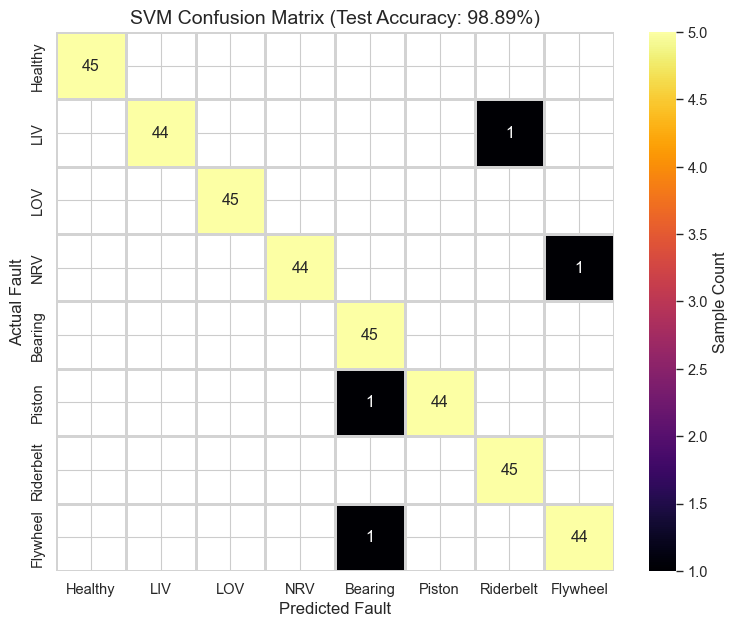

In [ ]:
# ─────────────────────────────────────────────────────────
# SVM Confusion Matrix — Error Focus (Raw Counts)
# ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from mrmr import mrmr_classif
from svm_classifier import SVMFaultClassifier, grid_search_svm

X = np.load('features.npy')
y = np.load('labels.npy')

# Identical split to the XGBoost notebook
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# mRMR feature selection (fit on train only — no leakage)
with open('best_model_configs.pkl', 'rb') as f:
    best_model_configs = pickle.load(f)

best_svm = best_model_configs['svm']
N_FEAT, best_C, best_gamma = best_svm['n_feat'], best_svm['C'], best_svm['gamma']

selected = mrmr_classif(pd.DataFrame(X_train), pd.Series(y_train), K=N_FEAT, show_progress=False)
X_train_sel = X_train[:, selected]
X_test_sel  = X_test[:, selected]

# Scale
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# Grid search + fit
clf = SVMFaultClassifier(decomposition='DDAG', C=best_C, gamma=best_gamma)
clf.fit(X_train_sel, y_train)

svm_test_preds = clf.predict(X_test_sel)
svm_test_acc = accuracy_score(y_test, svm_test_preds)

print(f"🎯 SVM UNBIASED TEST ACCURACY: {svm_test_acc * 100:.2f}%")

# ─────────────────────────────────────────────────────────
# THE FIX: SMART COLOR SCALING & MASKING
# ─────────────────────────────────────────────────────────
fault_names = ['Healthy', 'LIV', 'LOV', 'NRV', 'Bearing', 'Piston', 'Riderbelt', 'Flywheel']

# 1. Get RAW counts
cm_svm = confusion_matrix(y_test, svm_test_preds)

# 2. Find the maximum ERROR count to cap the color scale.
# We temporarily zero out the diagonal on a copy just to find the max error value (e.g., 4 or 5)
cm_off_diag = cm_svm.copy()
np.fill_diagonal(cm_off_diag, 0)
max_error_count = cm_off_diag.max()

# Cap the color scale at max_error_count (or 5 minimum) so errors stand out.
vmax_val = max(max_error_count, 5)

# 3. Create a mask to completely hide any cell that has a 0 (reduces clutter)
mask = cm_svm == 0

plt.figure(figsize=(9, 7))

# Plot with the custom vmax. The diagonal will be max color, 0s will be blank, 
# and the errors will be clearly shaded based on their severity.
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='inferno', mask=mask,
            vmax=vmax_val,
            xticklabels=fault_names, yticklabels=fault_names,
            linewidths=1, linecolor='lightgray',
            cbar_kws={'label': 'Sample Count'})

plt.title(f"SVM Confusion Matrix (Test Accuracy: {svm_test_acc * 100:.2f}%)", fontsize=14)
plt.xlabel("Predicted Fault", fontsize=12)
plt.ylabel("Actual Fault", fontsize=12)
plt.show()

# VOTING-ENSEMBLE

In [34]:
# In the SVM notebook, replace the predict_proba block with:
from scipy.special import softmax

decision_scores = clf.clf.decision_function(X_test_sel)   # clf.clf is the underlying OneVsOneClassifier
svm_test_probs = softmax(decision_scores, axis=1)          # convert vote/margin scores -> pseudo-probabilities

np.save('svm_test_probs.npy', svm_test_probs)
np.save('svm_y_test.npy', y_test)
print(f"✅ Saved SVM pseudo-probabilities: shape {svm_test_probs.shape}")

✅ Saved SVM pseudo-probabilities: shape (360, 8)


🎯 ENSEMBLE TEST ACCURACY: 98.89%

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        45
         LIV       0.98      0.98      0.98        45
         LOV       1.00      1.00      1.00        45
         NRV       1.00      0.98      0.99        45
     Bearing       0.98      1.00      0.99        45
      Piston       1.00      0.98      0.99        45
   Riderbelt       0.98      0.98      0.98        45
    Flywheel       0.98      1.00      0.99        45

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



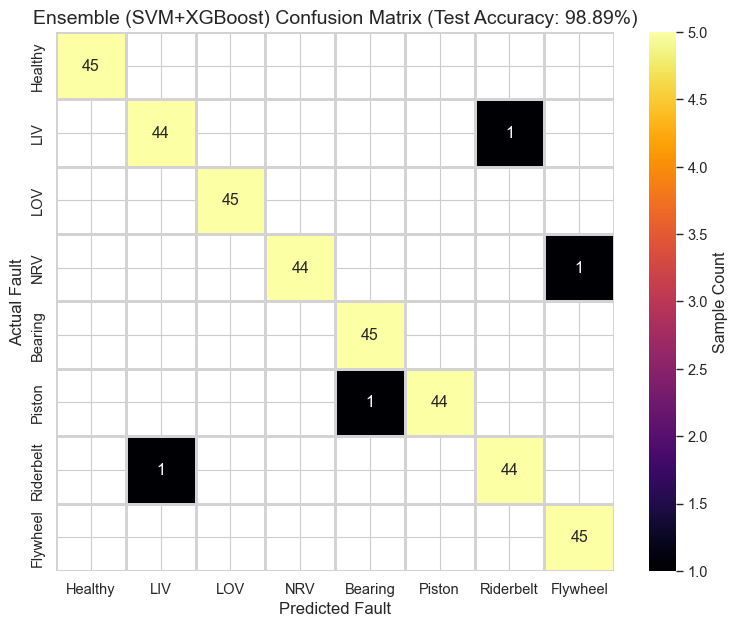

In [50]:
# ─────────────────────────────────────────────────────────
# Soft-Voting Ensemble: SVM + XGBoost
# ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

svm_test_probs = np.load('svm_test_probs.npy')
xgb_test_probs = np.load('xgb_test_probs.npy')
y_test_svm = np.load('svm_y_test.npy')
y_test_xgb = np.load('xgb_y_test.npy')

# Sanity check: the two notebooks MUST have produced the identical split
assert np.array_equal(y_test_svm, y_test_xgb), \
    "y_test mismatch between notebooks — splits don't match, do not trust the ensemble below!"
y_test = y_test_svm

# Weighted average (SVM was slightly ahead at 98.89% vs XGBoost's 98.33%, so weight it a touch higher)
SVM_WEIGHT = 0.55
XGB_WEIGHT = 0.45
ensemble_probs = SVM_WEIGHT * svm_test_probs + XGB_WEIGHT * xgb_test_probs
ensemble_preds = np.argmax(ensemble_probs, axis=1)

ensemble_acc = accuracy_score(y_test, ensemble_preds)
print(f"🎯 ENSEMBLE TEST ACCURACY: {ensemble_acc * 100:.2f}%")

fault_names = ['Healthy', 'LIV', 'LOV', 'NRV', 'Bearing', 'Piston', 'Riderbelt', 'Flywheel']
print("\nClassification Report:")
print(classification_report(y_test, ensemble_preds, target_names=fault_names))

# ─────────────────────────────────────────────────────────
# THE FIX: SMART COLOR SCALING & MASKING HEATMAP
# ─────────────────────────────────────────────────────────
# 1. Get RAW counts
cm_ensemble = confusion_matrix(y_test, ensemble_preds)

# 2. Find the maximum ERROR count to cap the color scale.
cm_off_diag = cm_ensemble.copy()
np.fill_diagonal(cm_off_diag, 0)
max_error_count = cm_off_diag.max()

# Cap the color scale at max_error_count (or 5 minimum) so errors stand out.
vmax_val = max(max_error_count, 5)

# 3. Create a mask to completely hide any cell that has a 0
mask = cm_ensemble == 0

plt.figure(figsize=(9, 7))

# Plot with the custom vmax and mask. 
# Using 'Purples' to keep the Ensemble visually distinct from SVM (Reds) and XGB (Blues)
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='inferno', mask=mask,
            vmax=vmax_val,
            xticklabels=fault_names, yticklabels=fault_names,
            linewidths=1, linecolor='lightgray',
            cbar_kws={'label': 'Sample Count'})

plt.title(f"Ensemble (SVM+XGBoost) Confusion Matrix (Test Accuracy: {ensemble_acc * 100:.2f}%)", fontsize=14)
plt.xlabel("Predicted Fault", fontsize=12)
plt.ylabel("Actual Fault", fontsize=12)
plt.show()

# META-LEARNER ENSEMBLE

In [ ]:
import numpy as np
from scipy.special import softmax
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
oof_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=2024)  # fixed seed, must match XGB notebook exactly

svm_oof_probs = np.zeros((X_train.shape[0], 8))  # 8 classes

for fold_idx, (tr_idx, val_idx) in enumerate(oof_skf.split(X_train_sel, y_train)):
    X_tr, X_val = X_train_sel[tr_idx], X_train_sel[val_idx]
    y_tr = y_train[tr_idx]

    fold_clf = SVMFaultClassifier(decomposition='DDAG', C=best_C, gamma=best_gamma)
    fold_clf.fit(X_tr, y_tr)

    decision_scores = fold_clf.clf.decision_function(X_val)
    svm_oof_probs[val_idx] = softmax(decision_scores, axis=1)
    print(f"  Fold {fold_idx+1}/{N_FOLDS} done")

# Final SVM, trained on ALL of X_train, for test-set predictions
final_svm = SVMFaultClassifier(decomposition='DDAG', C=best_C, gamma=best_gamma)
final_svm.fit(X_train_sel, y_train)
svm_test_probs = softmax(final_svm.clf.decision_function(X_test_sel), axis=1)

np.save('svm_oof_probs.npy', svm_oof_probs)
np.save('svm_test_probs.npy', svm_test_probs)
np.save('meta_y_train.npy', y_train)
np.save('meta_y_test.npy', y_test)
print("✅ Saved SVM OOF + test probabilities for stacking")

  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
✅ Saved SVM OOF + test probabilities for stacking


🎯 STACKED META-LEARNER TEST ACCURACY: 98.89%

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        45
         LIV       0.98      0.98      0.98        45
         LOV       1.00      1.00      1.00        45
         NRV       1.00      0.98      0.99        45
     Bearing       0.98      1.00      0.99        45
      Piston       1.00      0.98      0.99        45
   Riderbelt       0.98      0.98      0.98        45
    Flywheel       0.98      1.00      0.99        45

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360


📊 Meta-learner coefficient magnitudes (SVM cols 0-7, XGBoost cols 8-15):
  Mean |coef| on SVM columns:     0.7884
  Mean |coef| on XGBoost columns: 0.7973


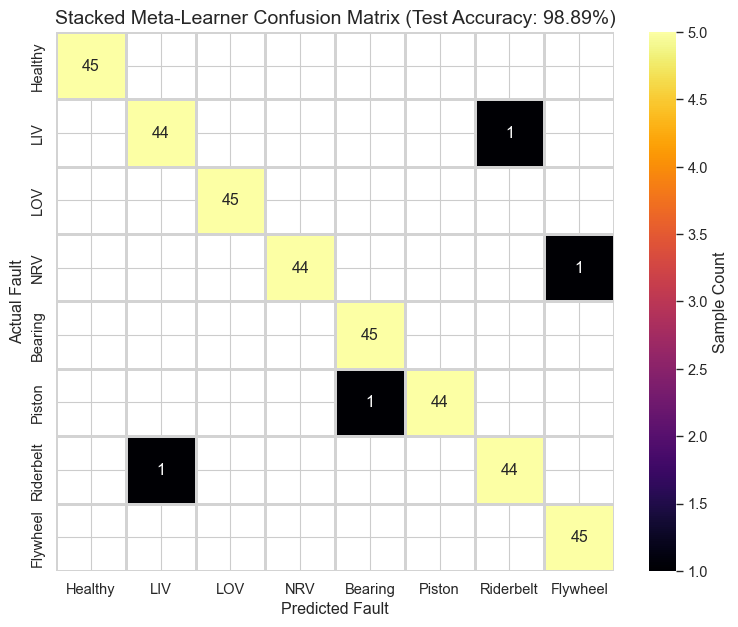

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

svm_oof = np.load('svm_oof_probs.npy')
xgb_oof = np.load('xgb_oof_probs.npy')
svm_test = np.load('svm_test_probs.npy')
xgb_test = np.load('xgb_test_probs.npy')
y_train_meta = np.load('meta_y_train.npy')
y_test_meta = np.load('meta_y_test.npy')

# Meta-features: concatenate both models' probability vectors → 16 columns (8+8)
meta_X_train = np.hstack([svm_oof, xgb_oof])
meta_X_test = np.hstack([svm_test, xgb_test])

# Meta-learner: simple, regularized — with only ~1440 train rows and 16 features,
# a complex meta-model would just overfit. Logistic regression is the standard choice here.
meta_clf = LogisticRegression(max_iter=2000, C=1.0)
meta_clf.fit(meta_X_train, y_train_meta)

meta_preds = meta_clf.predict(meta_X_test)
meta_acc = accuracy_score(y_test_meta, meta_preds)

print(f"🎯 STACKED META-LEARNER TEST ACCURACY: {meta_acc * 100:.2f}%")
print("\nClassification Report:")
fault_names = ['Healthy', 'LIV', 'LOV', 'NRV', 'Bearing', 'Piston', 'Riderbelt', 'Flywheel']
print(classification_report(y_test_meta, meta_preds, target_names=fault_names))

# Inspect what the meta-learner actually learned: does it trust SVM or XGBoost more?
print("\n📊 Meta-learner coefficient magnitudes (SVM cols 0-7, XGBoost cols 8-15):")
coef_importance = np.abs(meta_clf.coef_).mean(axis=0)
print(f"  Mean |coef| on SVM columns:     {coef_importance[:8].mean():.4f}")
print(f"  Mean |coef| on XGBoost columns: {coef_importance[8:].mean():.4f}")

# ─────────────────────────────────────────────────────────
# THE FIX: SMART COLOR SCALING & MASKING HEATMAP
# ─────────────────────────────────────────────────────────
# 1. Get RAW counts instead of normalized percentages
cm_meta = confusion_matrix(y_test_meta, meta_preds)

# 2. Find the maximum ERROR count to cap the color scale.
cm_off_diag = cm_meta.copy()
np.fill_diagonal(cm_off_diag, 0)
max_error_count = cm_off_diag.max()

# Cap the color scale at max_error_count (or 5 minimum) so errors stand out.
vmax_val = max(max_error_count, 5)

# 3. Create a mask to completely hide any cell that has a 0
mask = cm_meta == 0

plt.figure(figsize=(9, 7))

# Plot with the custom vmax and mask. 
# Using 'Greens' to keep the Meta-Learner visually distinct from the other models
sns.heatmap(cm_meta, annot=True, fmt='d', cmap='inferno', mask=mask,
            vmax=vmax_val,
            xticklabels=fault_names, yticklabels=fault_names,
            linewidths=1, linecolor='lightgray',
            cbar_kws={'label': 'Sample Count'})

plt.title(f"Stacked Meta-Learner Confusion Matrix (Test Accuracy: {meta_acc * 100:.2f}%)", fontsize=14)
plt.xlabel("Predicted Fault")
plt.ylabel("Actual Fault")
plt.show()